# Customer Churn Prediction

## 1. Introduction

Customer churn is an important challenge for subscription-based companies.
Understanding why customers leave can help businesses identify at-risk customers
and improve customer retention.

In this project, we analyze a telecommunications customer dataset and investigate
the factors associated with customer churn.

The objective is to explore the dataset, identify patterns related to churn,
and build machine learning models capable of predicting whether a customer is
likely to churn.

### Project Objectives

- Understand the structure of the customer dataset
- Explore customer characteristics and churn patterns
- Clean and prepare the data
- Identify features associated with churn
- Build and evaluate machine learning models

## 2. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Overview

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Target Variable Distribution

The target variable, Churn, indicates whether a customer left the company.

The dataset is imbalanced, with approximately 73.5% of customers who did not churn
and 26.5% who churned.

This imbalance should be taken into account when evaluating machine learning models.

## 4. Data Cleaning

Before encoding the categorical variables, we first convert `TotalCharges` to a numerical format.

The `customerID` column is an identifier and does not provide useful predictive information, so it will be removed before model training.

In [10]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check for missing values created during conversion
df["TotalCharges"].isnull().sum()

np.int64(11)

In [11]:
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [12]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [13]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [14]:
df[df["tenure"] == 0][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


### Handling Missing Values in `TotalCharges`

The dataset contains 11 missing values in `TotalCharges`. These missing values correspond to customers with a tenure of 0 months.

Since `TotalCharges` represents the total amount charged since the beginning of the subscription, a value of 0 is reasonable for these newly registered customers.

Therefore, the missing values are replaced with 0. The column is also converted to a numeric format to ensure it can be used correctly in subsequent analysis and modeling.

## 5. Exploratory Data Analysis

### 5.1. Churn distribution

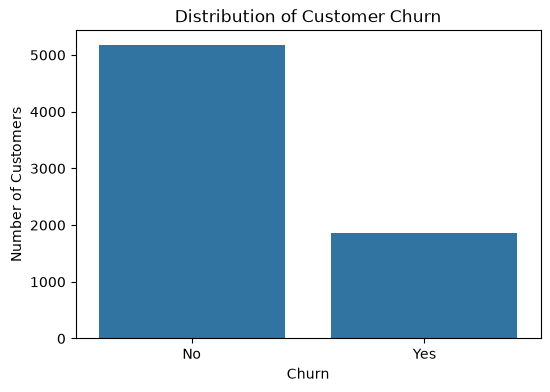

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### 5.2. Categorical features

In [16]:
eda_categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [17]:
for feature in eda_categorical_features:
    churn_rate = (
        df.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )
    
    print(f"\n{feature}")
    print(churn_rate.round(1))


gender
gender
Female    26.9
Male      26.2
Name: Churn, dtype: float64

SeniorCitizen
SeniorCitizen
0    23.6
1    41.7
Name: Churn, dtype: float64

Partner
Partner
No     33.0
Yes    19.7
Name: Churn, dtype: float64

Dependents
Dependents
No     31.3
Yes    15.5
Name: Churn, dtype: float64

PhoneService
PhoneService
No     24.9
Yes    26.7
Name: Churn, dtype: float64

MultipleLines
MultipleLines
No                  25.0
No phone service    24.9
Yes                 28.6
Name: Churn, dtype: float64

InternetService
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No                     41.8
No internet service     7.4
Yes                    14.6
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No                     39.9
No internet service     7.4
Yes                    21.5
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No                     39.1
No internet service     7.4
Y

#### Churn and Contract Type

In [18]:
churn_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

churn_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


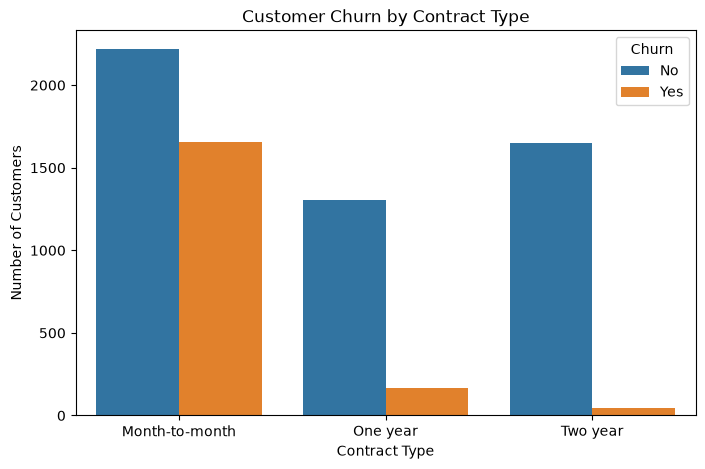

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

**Key findings**

Customers with month-to-month contracts have a much higher churn rate
  (**42.7%**) compared with customers on one-year (**11.3%**) or two-year contracts (**2.8%**).

These findings suggest that contract type is an important variable for predicting churn. However, this relationship is associative and does not imply causality.

#### Churn and Internet Service

In [20]:
churn_internet = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

churn_internet

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


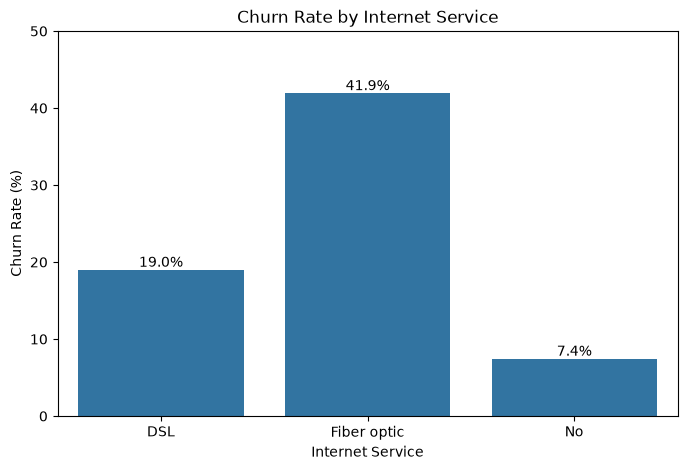

In [21]:
churn_rate_internet = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=churn_rate_internet,
    x="InternetService",
    y="ChurnRate"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 50)
plt.show()

**Key findings**

The churn rate varies substantially across Internet service types.

- Fiber optic customers have the highest churn rate (**41.9%**).
- DSL customers have a lower churn rate (**19.0%**).
- Customers without Internet service have the lowest churn rate (**7.4%**).

The particularly high churn rate among Fiber optic customers is an important
finding that requires further investigation. This association does not imply
that Fiber optic service itself causes customer churn.

#### Churn and Payment Method

In [22]:
churn_payment = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

churn_payment

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


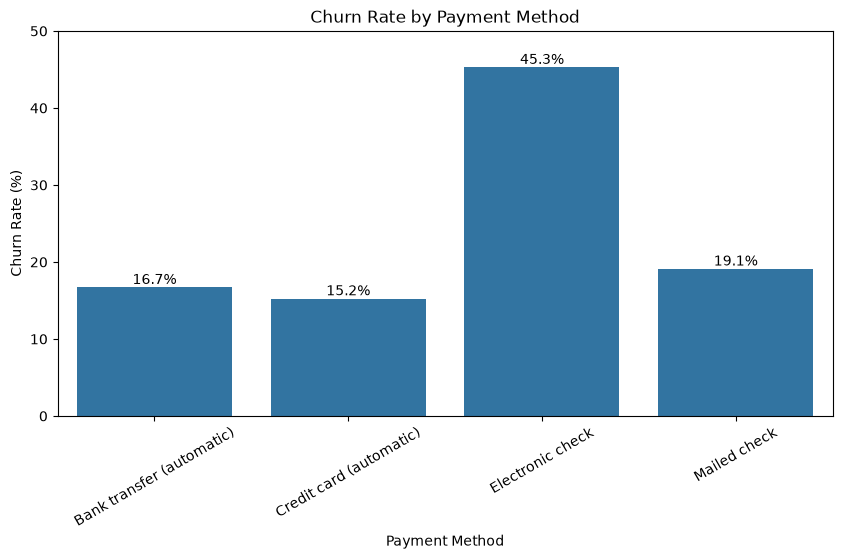

In [23]:
churn_rate_payement = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=churn_rate_payement,
    x="PaymentMethod",
    y="ChurnRate"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 50)
plt.xticks(rotation=30)

plt.show()

**Key findings**

The churn rate varies significantly depending on the payment method.

Customers using Electronic check have a churn rate of approximately **45.3%**. This rate is much higher than for the other payment methods:
- **Mailed check:** 19.1%
- **Bank transfer (automatic):** 16.7%
- **Credit card (automatic):** 15.2%

Customers using automatic payment methods, such as bank transfer or credit card, have considerably lower churn rates.

This suggests that PaymentMethod is strongly associated with customer churn.
In particular, customers using Electronic check appear to be a high-risk group.

However, this analysis shows an association rather than a causal relationship.Other factors, such as contract type, tenure, or monthly charges, may also contribute to the higher churn rate observed among Electronic check users.

#### Churn and Senior Citizen Status

In [24]:
churn_senior = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

churn_senior

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


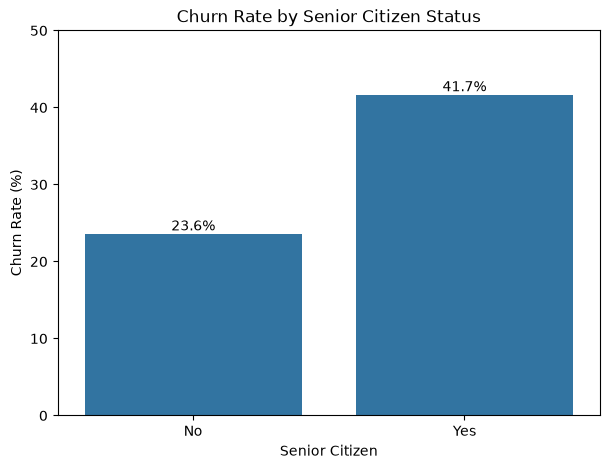

In [25]:
churn_rate_senior = (
    df.groupby("SeniorCitizen")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=churn_rate_senior,
    x="SeniorCitizen",
    y="ChurnRate"
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 50)

plt.xticks([0, 1], ["No", "Yes"])

plt.show()

**Key findings**

The churn rate differs significantly between senior and non-senior customers.

- **Non-senior customers:** 23.6% churn rate
- **Senior customers:** 41.7% churn rate

Senior customers have an observed churn rate about 1.8 times higher than non-senior customers.

This suggests that **SeniorCitizen is an important variable associated with customer churn** in this dataset.

However, this result does not imply a causal relationship. Other factors, such as contract type, tenure, payment method, or monthly charges, may also contribute to this difference.

#### Churn and Partner Status

In [26]:
churn_partner = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

churn_partner

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


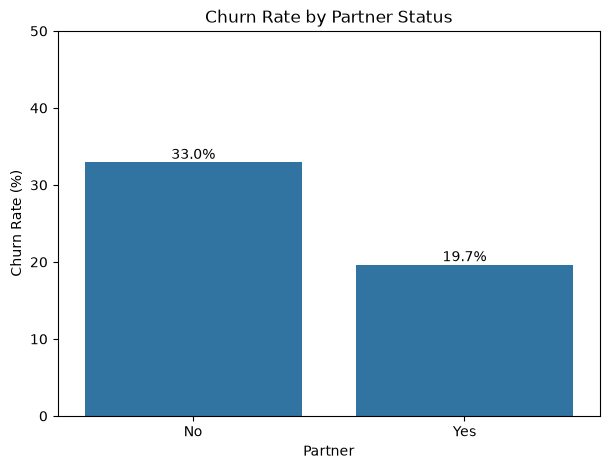

In [27]:
churn_rate_partner = (
    df.groupby("Partner")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=churn_rate_partner,
    x="Partner",
    y="ChurnRate"
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 50)

plt.xticks([0, 1], ["No", "Yes"])

plt.show()

**Key findings**

Customers without a partner have a higher churn rate (**33.0%**) compared with customers who have a partner (**19.7%**).

This suggests that customers without a partner may be more likely to leave the company. However, this variable alone does not establish a causal relationship, and its effect may be related to other customer characteristics such as tenure, contract type, or monthly charges.

#### Churn and Dependents Status

In [28]:
churn_dependents = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

churn_dependents

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


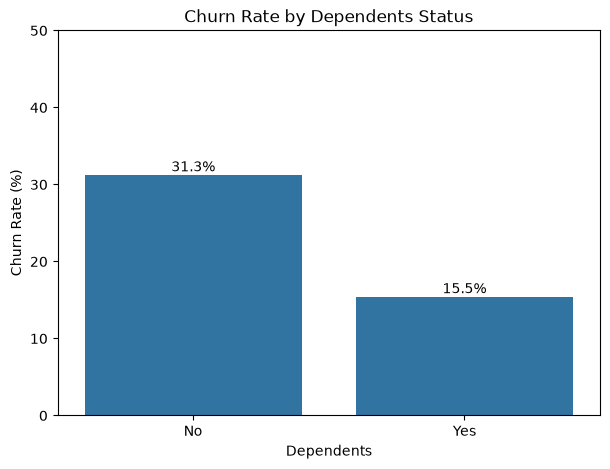

In [29]:
churn_rate_dependents = (
    df.groupby("Dependents")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=churn_rate_dependents,
    x="Dependents",
    y="ChurnRate"
)

plt.title("Churn Rate by Dependents Status")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 50)

plt.xticks([0, 1], ["No", "Yes"])

plt.show()

**Key findings**

Customers without dependents have a higher churn rate (**31.3%**) compared with customers with dependents (**15.5%**).

This suggests that customers without dependents are more likely to leave the company. However, this is an association rather than a causal relationship, and the difference may also be related to other customer characteristics such as tenure, contract type, or monthly charges.

#### Churn and Tech Support Status

In [30]:
churn_tech_support = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

churn_tech_support

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


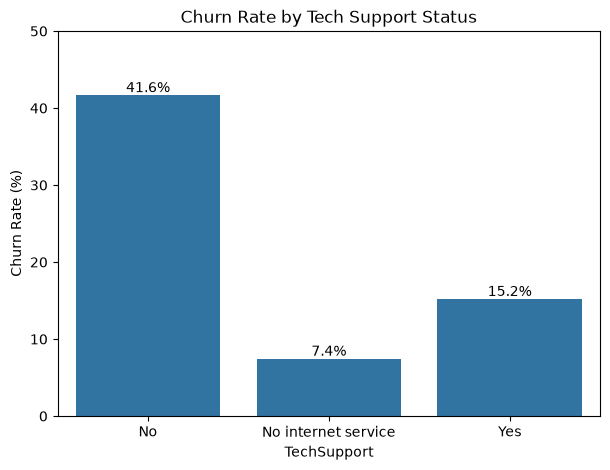

In [31]:
churn_rate_tech_support = (
    df.groupby("TechSupport")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=churn_rate_tech_support,
    x="TechSupport",
    y="ChurnRate"
)

plt.title("Churn Rate by Tech Support Status")
plt.xlabel("TechSupport")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 50)



plt.show()

**Key findings**

Customers without Tech Support have a substantially higher churn rate than customers with Tech Support.

Among customers with an Internet service, the churn rate is **41.6%** for those without Tech Support, compared with only **15.2%** for those with Tech Support. This represents a nearly threefold difference in churn rate.

Customers with no Internet service have the lowest churn rate (**7.4%**). However, this category is structurally different because Tech Support is not applicable to customers without an Internet service.

These results suggest that the absence of technical support is associated with a higher likelihood of churn. However, this association does not imply causality, as other factors such as contract type, tenure, and monthly charges may also contribute to customer churn.

#### Churn and Online Security Status

In [32]:
churn_online_security = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

churn_online_security

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


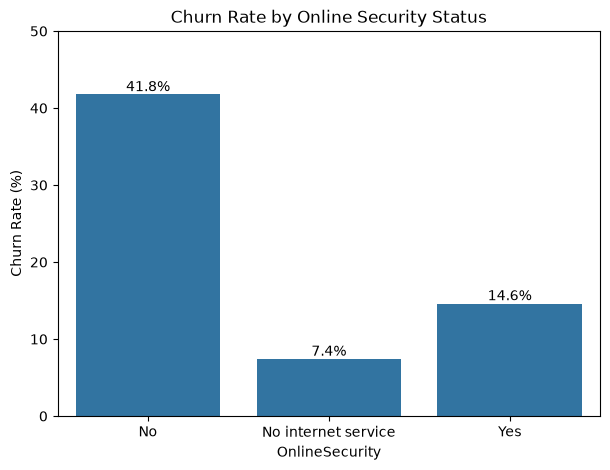

In [33]:
churn_rate_online_security = (
    df.groupby("OnlineSecurity")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=churn_rate_online_security,
    x="OnlineSecurity",
    y="ChurnRate"
)

plt.title("Churn Rate by Online Security Status")
plt.xlabel("OnlineSecurity")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 50)



plt.show()

**Key findings**

Customers without Online Security have a substantially higher churn rate than customers with Online Security.

Among customers with an Internet service, the churn rate is **41.8%** for those without Online Security, compared with only **14.6%** for those with Online Security. This represents a nearly threefold difference in churn rate.

Customers with no Internet service have the lowest churn rate (**7.4%**). However, this category is structurally different because Online Security is not applicable to customers without an Internet service.

These results suggest that the absence of online security is associated with a higher likelihood of churn. However, this association does not imply causality, as other factors such as contract type, tenure, and monthly charges may also contribute to customer churn.

#### Churn and Online Backup Status

In [34]:
churn_online_backup = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

churn_online_backup

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


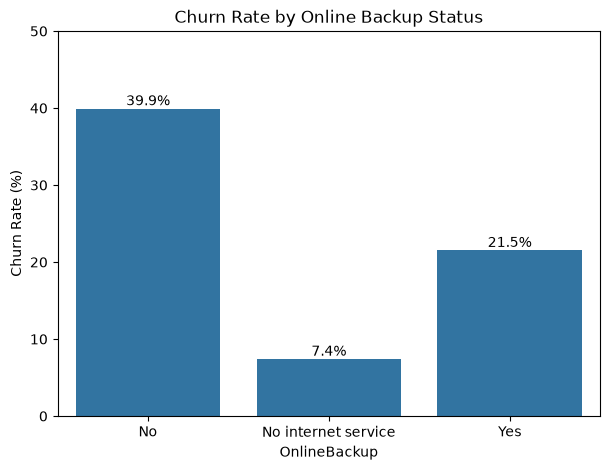

In [35]:
churn_rate_online_backup = (
    df.groupby("OnlineBackup")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=churn_rate_online_backup,
    x="OnlineBackup",
    y="ChurnRate"
)

plt.title("Churn Rate by Online Backup Status")
plt.xlabel("OnlineBackup")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 50)



plt.show()

**Key findings**

Customers without Online Backup have a substantially higher churn rate than customers with Online Backup.

Among customers with an Internet service, the churn rate is **39.9%** for those without Online Backup, compared with only **21.5%** for those with Online Backup. This represents a nearly double difference in churn rate.

Customers with no Internet service have the lowest churn rate (**7.4%**). However, this category is structurally different because Online Backup is not applicable to customers without an Internet service.

These results suggest that the absence of online backup is associated with a higher likelihood of churn. However, this association does not imply causality, as other factors such as contract type, tenure, and monthly charges may also contribute to customer churn.

#### Churn and Device Protection Status

In [36]:
churn_device_protection = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

churn_device_protection

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


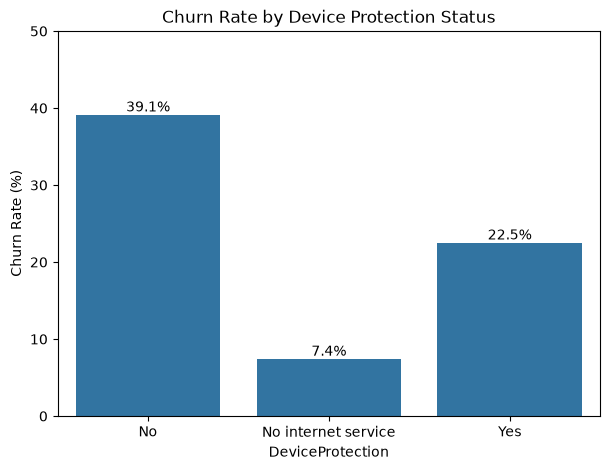

In [37]:
churn_rate_device_protection = (
    df.groupby("DeviceProtection")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=churn_rate_device_protection,
    x="DeviceProtection",
    y="ChurnRate"
)

plt.title("Churn Rate by Device Protection Status")
plt.xlabel("DeviceProtection")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 50)



plt.show()

**Key findings**

Customers without Device Protection have a substantially higher churn rate than customers with Device Protection.

Among customers with an Internet service, the churn rate is **39.1%** for those without Device Protection, compared with only **22.5%** for those with Device Protection. This represents a nearly double difference in churn rate.

Customers with no Internet service have the lowest churn rate (**7.4%**). However, this category is structurally different because Device Protection is not applicable to customers without an Internet service.

These results suggest that the absence of device protection is associated with a higher likelihood of churn. However, this association does not imply causality, as other factors such as contract type, tenure, and monthly charges may also contribute to customer churn.

#### Churn and Streaming TV Status

In [38]:
churn_streaming_tv = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

churn_streaming_tv

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


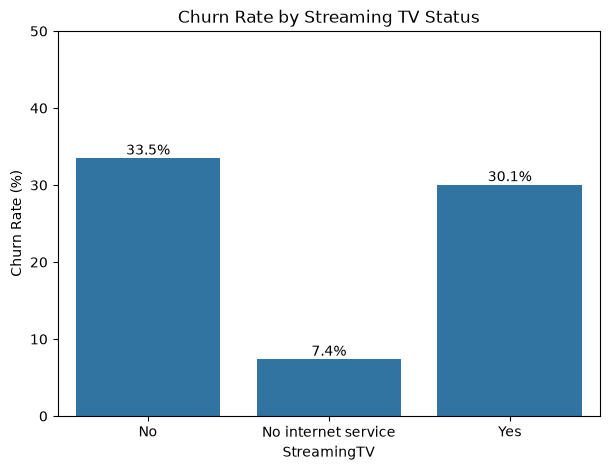

In [39]:
churn_rate_streaming_tv = (
    df.groupby("StreamingTV")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=churn_rate_streaming_tv,
    x="StreamingTV",
    y="ChurnRate"
)

plt.title("Churn Rate by Streaming TV Status")
plt.xlabel("StreamingTV")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 50)



plt.show()

**Key findings**

Among customers with an Internet service, the churn rate is slightly higher for customers without Streaming TV (**33.5%**) compared with those with Streaming TV (**30.1%**).

The difference is relatively small, suggesting that Streaming TV may have a limited association with customer churn compared with other service-related features.

Customers with no Internet service have a lower churn rate (**7.4%**). However, this category is structurally different because Streaming TV is not applicable to customers without an Internet service.

Overall, Streaming TV does not appear to be a strong standalone predictor of churn. However, its relationship with churn may depend on other factors such as contract type, tenure, and monthly charges.

#### Churn and Streaming Movies Status

In [40]:
churn_streaming_movies = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

churn_streaming_movies

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


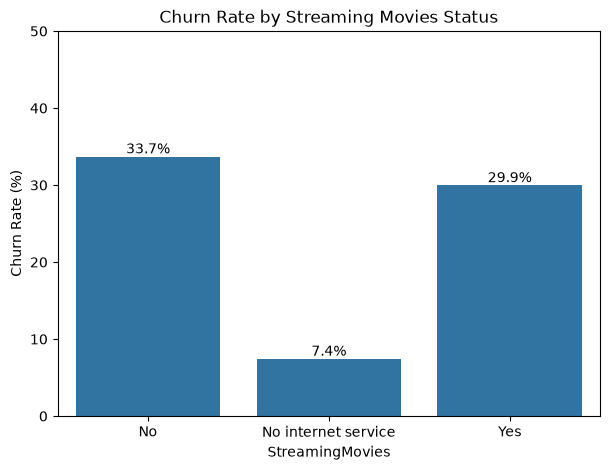

In [41]:
churn_rate_streaming_movies = (
    df.groupby("StreamingMovies")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=churn_rate_streaming_movies,
    x="StreamingMovies",
    y="ChurnRate"
)

plt.title("Churn Rate by Streaming Movies Status")
plt.xlabel("StreamingMovies")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 50)



plt.show()

**Key findings**

Among customers with an Internet service, the churn rate is slightly higher for customers without Streaming Movies (**33.7%**) compared with those with Streaming Movies (**29.9%**).

The difference is relatively small, suggesting that Streaming Movies may have a limited association with customer churn compared with other service-related features.

Customers with no Internet service have a lower churn rate (**7.4%**). However, this category is structurally different because Streaming Movies is not applicable to customers without an Internet service.

Overall, Streaming Movies does not appear to be a strong standalone predictor of churn. However, its relationship with churn may depend on other factors such as contract type, tenure, and monthly charges.

### 5.3. Numerical Features and Churn

#### Churn and Tenure

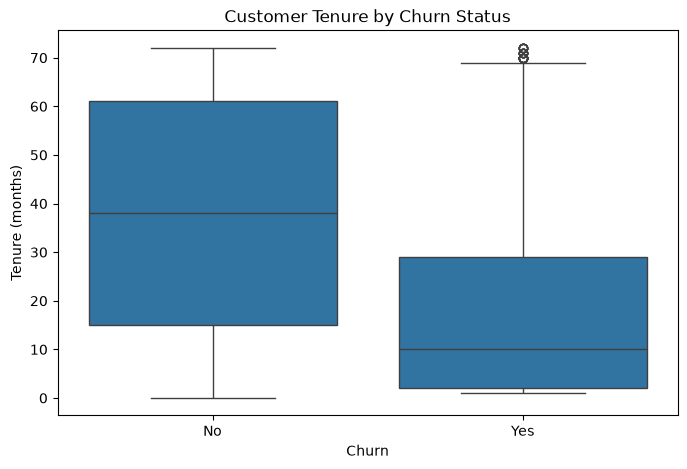

In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")

plt.show()

In [43]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


**Key findings**

Customers who churn tend to have substantially lower tenure.

The median tenure is **10 months** for churned customers, compared with **38 months** for customers who stayed.

These findings suggest that customer tenure is an important variable for predicting churn. However, this relationship is associative and does not imply causality.

#### Churn and Monthly Charges

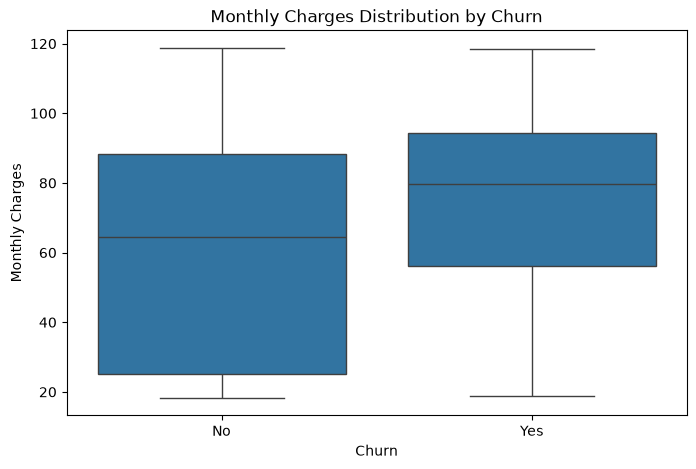

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [45]:
df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median"])

,mean,median
Churn,,
No,61.265124,64.425
Yes,74.441332,79.650


**Key Findings**

Customers who churned have higher monthly charges than customers who remained with the company.

- Average monthly charge for customers who stayed: **61.27€**
- Average monthly charge for customers who churned: **74.44€**
- Median monthly charge for customers who stayed: **64.43€**
- Median monthly charge for customers who churned: **79.65€**

#### Churn and Total Charges

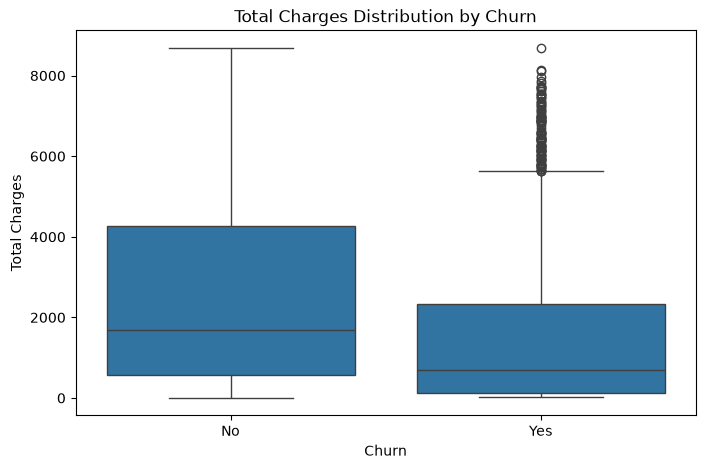

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

In [47]:
df.groupby("Churn")["TotalCharges"].agg(["mean", "median"])

,mean,median
Churn,,
No,2549.911442,1679.525
Yes,1531.796094,703.550


**Key Findings**

Customers who churn have substantially lower total charges on average than customers who remain with the company.

The mean TotalCharges is approximately **1531.80€** for churned customers, compared with **2549.91€** for customers who stayed.

The median TotalCharges is also lower for churned customers (**703.55€**) than for customers who stayed (**1679.53€**).

This difference is closely related to the lower tenure observed among churned customers, since TotalCharges accumulates over the duration of the subscription.

Therefore, TotalCharges should not be interpreted independently of tenure.

## 6. Relationships Between Features and Churn

### Interaction Between Internet Service, Monthly Charges and Churn

In [48]:
df.groupby("InternetService")["MonthlyCharges"].mean()

InternetService
DSL            58.102169
Fiber optic    91.500129
No             21.079194
Name: MonthlyCharges, dtype: float64

#### **Key findings**

Monthly charges vary considerably by Internet service:

- No Internet: €21.08
- DSL: €58.10
- Fiber optic: €91.50

The high churn rate observed among Fiber optic customers may therefore
be associated with their higher monthly charges. However, this does not
establish a causal relationship between price and churn.

In [49]:
df.groupby(["InternetService", "Churn"])["MonthlyCharges"].mean()

InternetService  Churn
DSL              No       60.212105
                 Yes      49.083224
Fiber optic      No       93.932379
                 Yes      88.126484
No               No       21.136058
                 Yes      20.368142
Name: MonthlyCharges, dtype: float64

#### **Key findings**

Previous analysis reveals a strong association between Internet service type and customer churn.

Fiber optic customers have the highest churn rate (**41.9%**), compared with
**19.0%** for DSL customers and **7.4%** for customers without Internet service.

However, monthly charges alone do not appear to explain this difference.
Within each Internet service category, customers who churned do not have
higher average monthly charges than customers who stayed.

For example, among Fiber optic customers:
- Customers who stayed: **93.93€** average monthly charges
- Customers who churned: **88.13€** average monthly charges

Therefore, the high churn rate among Fiber optic customers cannot be
explained simply by higher monthly charges. Other factors should be
investigated, such as contract type, tenure, payment method, or additional
services.

### Interaction Between Tenure, Monthly Charges and Churn

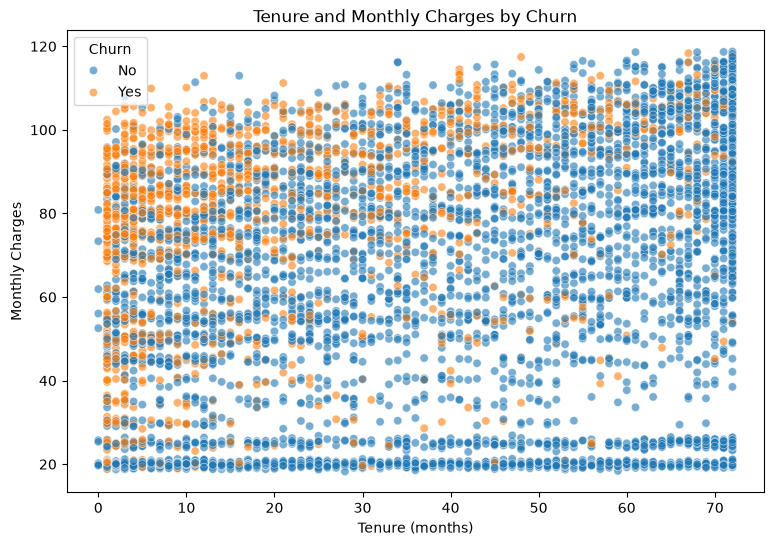

In [50]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Tenure and Monthly Charges by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly Charges")

plt.show()

#### **Key Findings**

Churned customers generally have shorter tenures and higher monthly charges than customers who remain with the company.

The scatter plot shows that churn is particularly concentrated among customers with shorter tenures, while customers with longer tenures are more frequently associated with no churn.

This suggests that tenure and monthly charges provide complementary information for understanding customer churn.

### Correlation Matrix

In [51]:
df["Churn_encoded"] = df["Churn"].map({"No": 0, "Yes": 1})

In [52]:
correlation_matrix = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn_encoded"]
].corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_encoded
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.103006,0.826178,0.651174,1.000000,-0.198324
Churn_encoded,0.150889,-0.352229,0.193356,-0.198324,1.000000


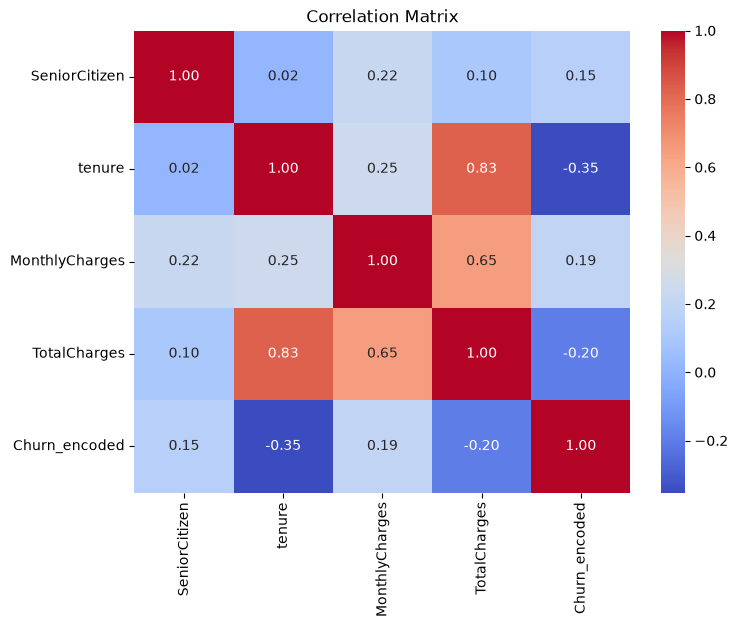

In [53]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

#### **Key Findings**

Tenure has the strongest linear relationship with churn among the numerical features, with a negative correlation of -0.35. This indicates that customers with longer tenures tend to be less likely to churn.

MonthlyCharges has a positive correlation with churn of 0.19, suggesting that higher monthly charges are moderately associated with churn.

TotalCharges has a negative correlation with churn of -0.20. This relationship is partly related to tenure, as TotalCharges is strongly correlated with tenure (0.83).

Overall, the correlation analysis highlights tenure as an important feature associated with churn, while also showing that the relationships between individual numerical variables and churn are not extremely strong.

## 7. EDA Summary

The exploratory analysis identified several customer characteristics that are strongly associated with churn.

Customers with month-to-month contracts and shorter tenure show substantially higher observed churn rates. Higher churn rates are also observed among customers using electronic checks, customers without Online Security or Tech Support, and Fiber optic customers.

Among numerical variables, churned customers tend to have higher monthly charges and substantially lower tenure and total charges. The lower TotalCharges observed among churned customers is closely related to their shorter tenure.

In contrast, some features such as gender, PhoneService, StreamingTV, and StreamingMovies show relatively small differences in observed churn rates.

These findings provide useful insights into customer churn and will guide the feature preparation and machine learning stages. However, the observed relationships are associative and should not be interpreted as causal effects.

## 8. Data Preprocessing 

### 8.1 Define features and target

In [54]:
X = df.drop(
    columns=["Churn", "customerID", "Churn_encoded"],
    errors="ignore"
)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

### 8.2 Train/Test Split

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 8.3 Identify numerical and categorical features

The dataset contains both numerical and categorical features.

Numerical features contain quantitative values, while categorical features represent different groups or categories.

Identifying these two types of features is necessary because they require different preprocessing techniques before being used in machine learning models.

In [56]:
numerical_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [57]:
print("Numerical features:", numerical_features)
print("Number of numerical features:", len(numerical_features))

print("\nCategorical features:", categorical_features)
print("Number of categorical features:", len(categorical_features))

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Number of numerical features: 4

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Number of categorical features: 15


### 8.4 Encode and transform features

#### One-Hot Encoding

Categorical features need to be converted into numerical representations before being used by machine learning models.

One-Hot Encoding creates a binary column for each category of a categorical feature. This allows the model to use categorical information without assuming any numerical order between categories.

In [58]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore")

#### Applying the Preprocessing to Numerical and Categorical Features

The categorical features will be transformed using One-Hot Encoding, while the numerical features will be standardized.

A ColumnTransformer is used to apply the appropriate transformation to each group of features.

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

#### Transforming the Training and Test Sets

The preprocessing transformations are fitted on the training data and then applied to the test data.

This prevents information from the test set from being used during the training process.

In [60]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [61]:
print("Training set shape:", X_train_processed.shape)
print("Test set shape:", X_test_processed.shape)

Training set shape: (5634, 45)
Test set shape: (1409, 45)


#### Preprocessed Feature Dimensions

After preprocessing, the original 19 features are transformed into 45 numerical features.

The training and test sets have the same number of features, allowing them to be used consistently by machine learning models.

In [62]:
print("Number of features before preprocessing:", X_train.shape[1])
print("Number of features after preprocessing:", X_train_processed.shape[1])

Number of features before preprocessing: 19
Number of features after preprocessing: 45


## 9. Machine Learning

### 9.1. Establish a Baseline

Before training machine learning models, a simple baseline model is used as a reference point.

The baseline always predicts the majority class. Its performance provides a reference against which more advanced models can be compared.

In [63]:
from sklearn.dummy import DummyClassifier

In [64]:
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

In [65]:
baseline_model.fit(X_train_processed, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.73,0.27]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,45
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [66]:
y_pred_baseline = baseline_model.predict(X_test_processed)

In [67]:
from sklearn.metrics import accuracy_score

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.7345635202271115


### 9.2. Logistic Regression

Logistic Regression is used as the first machine learning model to predict customer churn.

It is a simple and interpretable classification algorithm that estimates the probability of a customer belonging to the churn class.

The model is trained on the preprocessed training data and evaluated on the test data.

In [68]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [69]:
logistic_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [70]:
y_pred_logistic = logistic_model.predict(
    X_test_processed
)

In [71]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.8055358410220014


### 9.3. Model Evaluation

Accuracy alone is not sufficient to evaluate the churn prediction model because the dataset is imbalanced.

Therefore, several classification metrics are used to evaluate the model from different perspectives:

- **Precision** measures how many predicted churn customers actually churned.
- **Recall** measures how many actual churn customers were correctly identified.
- **F1-score** provides a balance between precision and recall.
- **ROC-AUC** measures the model's ability to distinguish between churn and non-churn customers.
- **Confusion Matrix** shows the number of correct and incorrect predictions for each class.

#### 9.3.1. Classification report

In [72]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_logistic
))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



#### 9.3.2. Confusion Matrix

The confusion matrix provides a detailed view of the model's classification results.

It shows the number of:

- True Negatives (TN): customers correctly predicted as non-churn.
- False Positives (FP): customers incorrectly predicted as churn.
- False Negatives (FN): customers who churned but were predicted as non-churn.
- True Positives (TP): customers correctly predicted as churn.

This helps identify which type of prediction error is most common.

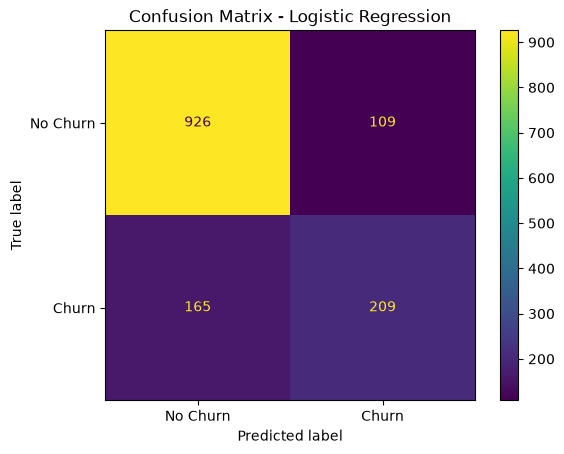

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Key Findings**

The confusion matrix shows that the Logistic Regression model correctly identifies **926** non-churned customers and **209** churned customers.

However, **165** customers who actually churned are incorrectly classified as non-churned.

This indicates that the model still misses a significant proportion of churned customers, which is reflected in the recall of **0.56** for the churn class.

The confusion matrix provides additional information that cannot be captured by accuracy alone.

#### 9.3.3. ROC-AUC

The ROC-AUC score evaluates the model's ability to distinguish between churned and non-churned customers.

ROC-AUC ranges from 0 to 1. A higher value indicates a better ability to distinguish between the two classes.

Unlike accuracy, ROC-AUC evaluates the model using its predicted probabilities rather than only the final class predictions.

In [74]:
from sklearn.metrics import roc_auc_score

y_proba_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

logistic_roc_auc = roc_auc_score(
    y_test,
    y_proba_logistic
)

print("Logistic Regression ROC-AUC:", logistic_roc_auc)

Logistic Regression ROC-AUC: 0.8421349040274871


**Key Findings**

The Logistic Regression model achieves a ROC-AUC score of **0.84**.

This indicates that the model has a good ability to distinguish between churned and non-churned customers.

The ROC-AUC complements accuracy, precision, recall, and F1-score by evaluating the model's ability to discriminate between the two classes based on predicted probabilities.

### 9.4. Random Forest

Random Forest is a tree-based ensemble learning algorithm.

It combines multiple decision trees to make predictions and can capture non-linear relationships between customer characteristics and churn.

A Random Forest model is trained on the same preprocessed training data and evaluated on the same test data.

In [75]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [76]:
random_forest_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [77]:
y_pred_rf = random_forest_model.predict(
    X_test_processed
)

In [78]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7750177430801988


#### Random Forest Evaluation

The Random Forest model is evaluated using the same classification metrics as the Logistic Regression model.

Using the same metrics and test set allows for a fair comparison between the two models.

In [79]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1035
           1       0.60      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



In [80]:
y_proba_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

rf_roc_auc = roc_auc_score(
    y_test,
    y_proba_rf
)

print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest ROC-AUC: 0.8194102146787569


### 9.5. Model Comparison

Two classification models were evaluated for customer churn prediction: Logistic Regression and Random Forest.

Both models were evaluated on the same test set using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

The results are summarized below.

In [81]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision (Churn)": [
        0.66,
        0.60
    ],
    "Recall (Churn)": [
        0.56,
        0.47
    ],
    "F1-score (Churn)": [
        0.60,
        0.53
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn),ROC-AUC
0,Logistic Regression,0.805536,0.66,0.56,0.60,0.842135
1,Random Forest,0.775018,0.60,0.47,0.53,0.819410


### Key Findings

The Logistic Regression model achieves higher Accuracy, Precision, Recall, F1-score, and ROC-AUC than the Random Forest model on the test set.

For the churn class, Logistic Regression achieves a recall of **0.56**, compared with **0.47** for Random Forest.

The results suggest that, with the current preprocessing and model configurations, Logistic Regression provides stronger performance for this churn prediction task.

However, model performance can depend on preprocessing choices, model hyperparameters, and the evaluation metric selected.

## 10. Model Improvement

### 10.1. Handling Class Imbalance

The target variable is imbalanced, with a larger proportion of non-churned customers than churned customers.

This class imbalance can affect model performance, particularly the ability to identify customers who churn.

Before applying any technique to address class imbalance, the class distribution is examined.

In [82]:
class_distribution = y_train.value_counts()

print("Class distribution:")
print(class_distribution)

print("\nClass proportions:")
print(y_train.value_counts(normalize=True))

Class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Class proportions:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


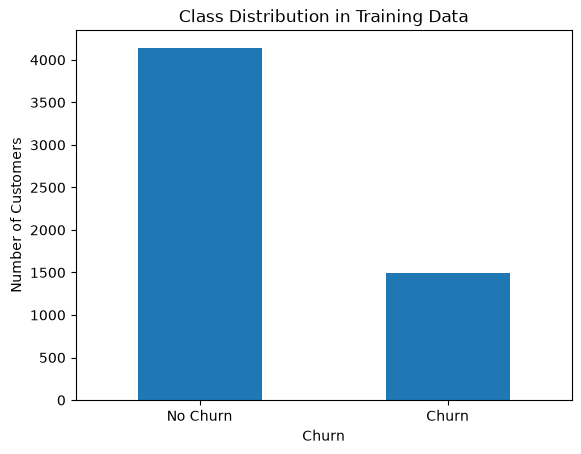

In [83]:
import matplotlib.pyplot as plt

class_distribution.plot(
    kind="bar"
)

plt.title("Class Distribution in Training Data")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(
    ticks=[0, 1],
    labels=["No Churn", "Churn"],
    rotation=0
)
plt.show()

#### Key Findings

The training data contains 4,139 non-churned customers (73.46%) and 1,495 churned customers (26.54%).

This shows a clear class imbalance, with non-churned customers representing the majority class.

Because churned customers are the minority class, accuracy alone may not fully reflect the model's ability to identify churned customers.

Therefore, techniques that account for class imbalance will be investigated to improve the detection of the churn class.

### 10.2. Using Class Weights

To address the class imbalance, a Logistic Regression model with balanced class weights is trained.

The `class_weight="balanced"` option automatically assigns higher weights to the minority class and lower weights to the majority class.

The goal is to improve the model's ability to identify churned customers.

In [84]:
from sklearn.linear_model import LogisticRegression

logistic_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [85]:
logistic_balanced.fit(
    X_train_processed,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [86]:
y_pred_balanced = logistic_balanced.predict(
    X_test_processed
)

In [87]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_balanced
))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### 10.3. ROC-AUC of the Balanced Logistic Regression

The balanced Logistic Regression model is evaluated using ROC-AUC to measure its ability to distinguish between churned and non-churned customers.

This metric complements precision, recall, and F1-score by evaluating the model based on predicted probabilities.

In [88]:
y_proba_balanced = logistic_balanced.predict_proba(
    X_test_processed
)[:, 1]

balanced_roc_auc = roc_auc_score(
    y_test,
    y_proba_balanced
)

print("Balanced Logistic Regression ROC-AUC:", balanced_roc_auc)

Balanced Logistic Regression ROC-AUC: 0.8416388953473353


### 10.4. Classification Threshold

The default classification threshold is 0.5.

However, the threshold can be adjusted to change the balance between precision and recall.

A lower threshold generally identifies more potential churn customers, which can increase recall but may also increase false positives.

Different thresholds can therefore be evaluated to understand their impact on churn detection.

In [89]:
y_proba_balanced[:10]

array([0.11772432, 0.85189963, 0.14625052, 0.66023441, 0.06044972,
       0.80508058, 0.69675764, 0.29176099, 0.00896026, 0.65222865])

In [90]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (
        y_proba_balanced >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1-score": f1_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,Threshold,Precision,Recall,F1-score
0,0.3,0.429988,0.927807,0.587638
1,0.4,0.466187,0.866310,0.606174
2,0.5,0.504303,0.783422,0.613613
3,0.6,0.539877,0.705882,0.611819


#### Key Findings

Lower classification thresholds increase recall but also lead to lower precision.

At a threshold of **0.3**, the model achieves a recall of **0.928** for the churn class, meaning that most churned customers are identified. However, precision decreases to **0.430**.

At a threshold of **0.6**, precision increases to **0.540**, while recall decreases to **0.706**.

Among the tested thresholds, **0.5** provides the highest F1-score (**0.614**), offering the best balance between precision and recall for this evaluation.

The appropriate threshold ultimately depends on the business objective and the relative cost of false positives and false negatives.

### 10.5. Model Interpretation

Logistic Regression provides interpretable coefficients that indicate how each feature is associated with the predicted probability of churn.

Because categorical variables were one-hot encoded during preprocessing, the model contains coefficients for the transformed features.

The coefficients will be examined to identify the features most strongly associated with higher or lower churn predictions.

In [91]:
feature_names = preprocessor.get_feature_names_out()

coefficients = logistic_balanced.coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient,Absolute_Coefficient
1,num__tenure,-1.154434,1.154434
38,cat__Contract_Two year,-0.775518,0.775518
16,cat__InternetService_Fiber optic,0.707981,0.707981
2,num__MonthlyCharges,-0.676114,0.676114
36,cat__Contract_Month-to-month,0.657713,0.657713
15,cat__InternetService_DSL,-0.622465,0.622465
3,num__TotalCharges,0.489698,0.489698
22,cat__OnlineBackup_No internet service,-0.275403,0.275403
31,cat__StreamingTV_No internet service,-0.275403,0.275403
25,cat__DeviceProtection_No internet service,-0.275403,0.275403


In [92]:
top_coefficients = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(10)

top_coefficients = top_coefficients.sort_values(
    "Coefficient"
)

top_coefficients

,Feature,Coefficient,Absolute_Coefficient
1,num__tenure,-1.154434,1.154434
38,cat__Contract_Two year,-0.775518,0.775518
2,num__MonthlyCharges,-0.676114,0.676114
15,cat__InternetService_DSL,-0.622465,0.622465
22,cat__OnlineBackup_No internet service,-0.275403,0.275403
31,cat__StreamingTV_No internet service,-0.275403,0.275403
25,cat__DeviceProtection_No internet service,-0.275403,0.275403
3,num__TotalCharges,0.489698,0.489698
36,cat__Contract_Month-to-month,0.657713,0.657713
16,cat__InternetService_Fiber optic,0.707981,0.707981


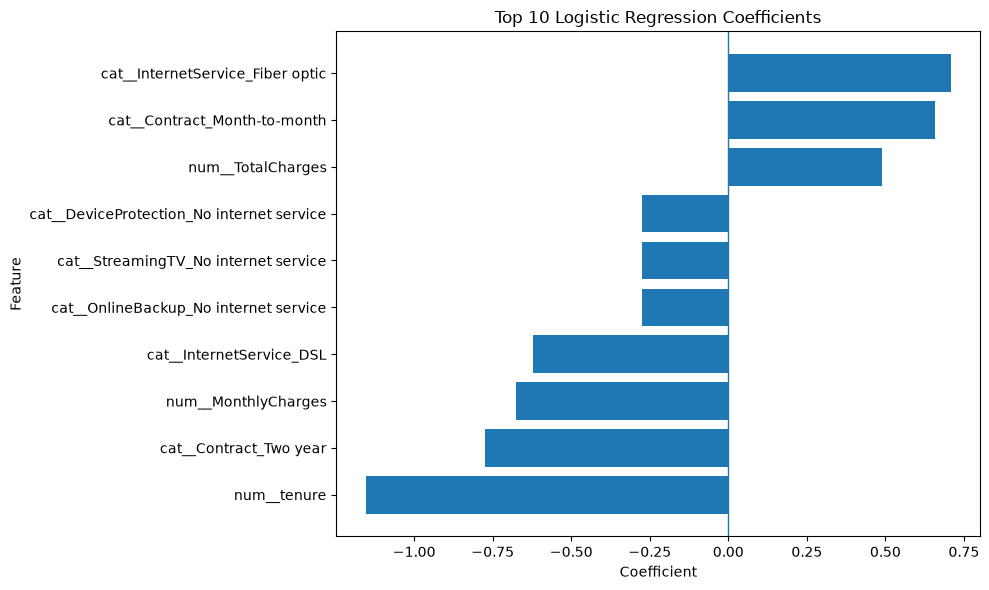

In [93]:
import matplotlib.pyplot as plt

top_coefficients = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(10)

top_coefficients = top_coefficients.sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.axvline(x=0, linewidth=1)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Logistic Regression Coefficients")

plt.tight_layout()
plt.show()

#### Key Findings

The Logistic Regression coefficients highlight several features that play an important role in the model's predictions.

Tenure has the largest absolute coefficient (**-1.154**), indicating a strong negative association with the predicted probability of churn.

Contract type is also important. Month-to-month contracts have a positive coefficient (**0.658**), while two-year contracts have a negative coefficient (**-0.776**).

Fiber optic Internet service has a positive coefficient (**0.708**), whereas DSL has a negative coefficient (**-0.622**).

These coefficients describe associations used by the model to generate predictions and should not be interpreted as causal effects.

### 10.6. Comparing the Original and Balanced Logistic Regression Models

The original Logistic Regression model and the balanced Logistic Regression model are compared to evaluate the impact of class weighting.

The original model uses the default class weights, while the balanced model gives more importance to the minority churn class.

The comparison focuses on Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [94]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

comparison_balanced = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_balanced)
    ],
    "Precision (Churn)": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_balanced)
    ],
    "Recall (Churn)": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_balanced)
    ],
    "F1-score (Churn)": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_balanced)
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        balanced_roc_auc
    ]
})

comparison_balanced

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn),ROC-AUC
0,Original Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
1,Balanced Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841639


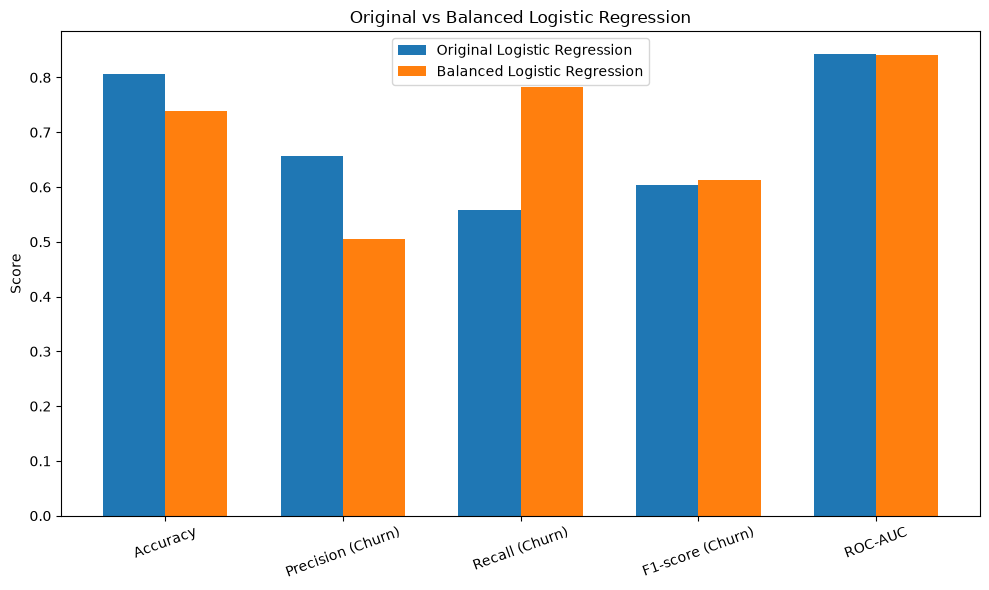

In [95]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision (Churn)",
    "Recall (Churn)",
    "F1-score (Churn)",
    "ROC-AUC"
]

original_values = comparison_balanced.loc[0, metrics].values
balanced_values = comparison_balanced.loc[1, metrics].values

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    [i - width / 2 for i in x],
    original_values,
    width=width,
    label="Original Logistic Regression"
)

plt.bar(
    [i + width / 2 for i in x],
    balanced_values,
    width=width,
    label="Balanced Logistic Regression"
)

plt.xticks(x, metrics, rotation=20)
plt.ylabel("Score")
plt.title("Original vs Balanced Logistic Regression")
plt.legend()

plt.tight_layout()
plt.show()

#### Key Findings

The balanced Logistic Regression model substantially increases recall for the churn class, from 0.559 to 0.783.

However, this improvement comes with a decrease in precision, from 0.657 to 0.504, and in overall accuracy, from 0.806 to 0.738.

The F1-score increases slightly from 0.604 to 0.614, while ROC-AUC remains almost unchanged (0.842 versus 0.842).

These results highlight the trade-off between identifying more churned customers and generating more false positive predictions.

The choice between the two models should therefore depend on the relative importance of recall, precision, and the costs associated with different types of prediction errors.

### 10.7. Selecting the Final Model

The comparison between the original and balanced Logistic Regression models shows a clear trade-off between precision and recall.

The original model achieves higher accuracy and precision, while the balanced model
achieves substantially higher recall for the churn class.

Since identifying customers who are likely to churn is an important objective of
this project, the balanced model provides a stronger focus on detecting the minority
churn class.

The balanced Logistic Regression model will therefore be used as the main model
for the next stages of the analysis, while keeping the original model as a useful
reference.

### 10.8. Final Model Evaluation

The balanced Logistic Regression model is evaluated in more detail using a confusion matrix, classification report, and ROC-AUC score.

These metrics provide a more complete view of the model's ability to identify both churned and non-churned customers.

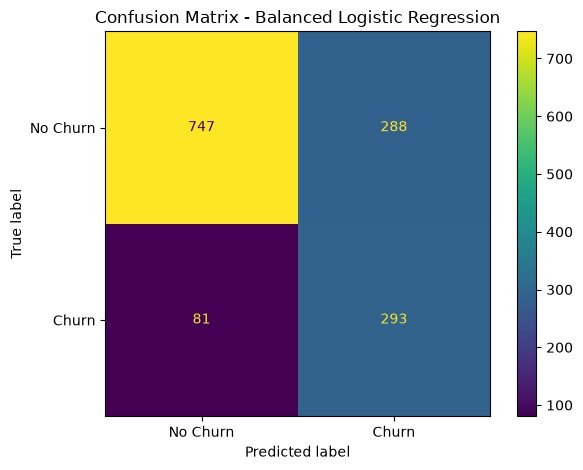

In [96]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.tight_layout()
plt.show()

#### Confusion Matrix - Key Findings

The balanced Logistic Regression model correctly identifies 293 churned customers and 747 non-churned customers.

It incorrectly classifies 288 non-churned customers as churned, resulting in false positives.

Only 81 churned customers are incorrectly classified as non-churned.

The relatively small number of false negatives is consistent with the model's recall of 0.783 for the churn class.

The confusion matrix highlights the trade-off introduced by class balancing: the model detects more churned customers, but it also produces more false positive predictions.

In [97]:
print("Classification Report - Balanced Logistic Regression")
print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=["No Churn", "Churn"]
    )
)

Classification Report - Balanced Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



#### Classification Report - Key Findings

The balanced Logistic Regression model achieves a recall of 0.78 for the churn class, meaning that it identifies a large proportion of the customers who actually churn.

However, precision for the churn class is 0.50, indicating that a substantial number of customers predicted as churners do not actually churn.

The F1-score for the churn class is 0.61, reflecting the balance between precision and recall.

For the non-churn class, the model achieves a precision of 0.90 and a recall of 0.72.

Overall accuracy is 0.74, while the macro-average F1-score is 0.71.

These results confirm the trade-off introduced by class balancing: the model prioritizes the detection of churned customers, resulting in higher recall but lower precision and accuracy compared with the original Logistic Regression model.

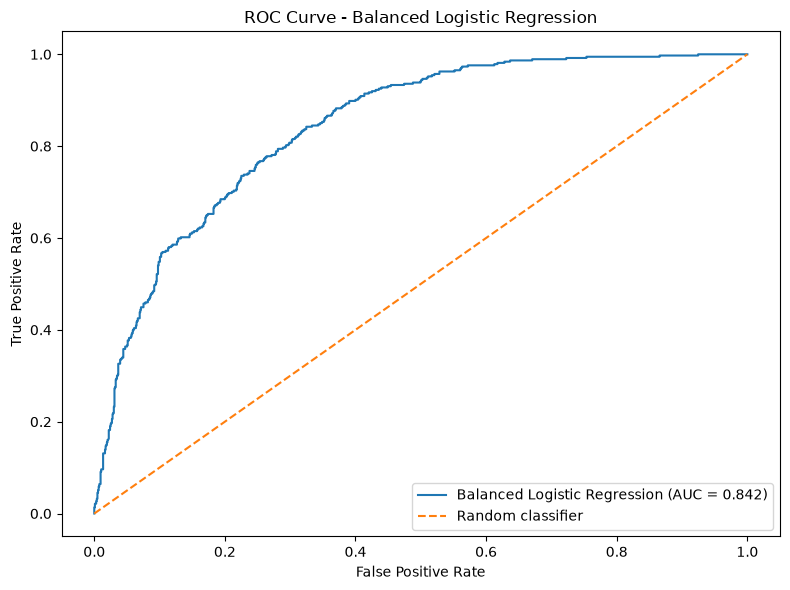

In [98]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba_balanced
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Balanced Logistic Regression (AUC = {balanced_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Balanced Logistic Regression")
plt.legend()

plt.tight_layout()
plt.show()

#### ROC Curve - Key Findings

The balanced Logistic Regression model achieves a ROC-AUC score of 0.842.

The ROC curve remains substantially above the random classifier baseline, indicating that the model has a good ability to distinguish between churned and non-churned customers.

The ROC-AUC is almost identical to that of the original Logistic Regression model (0.842), despite the substantial difference in precision and recall at the default classification threshold.

This indicates that class balancing mainly changes the model's classification behavior, while its overall ranking ability remains very similar.

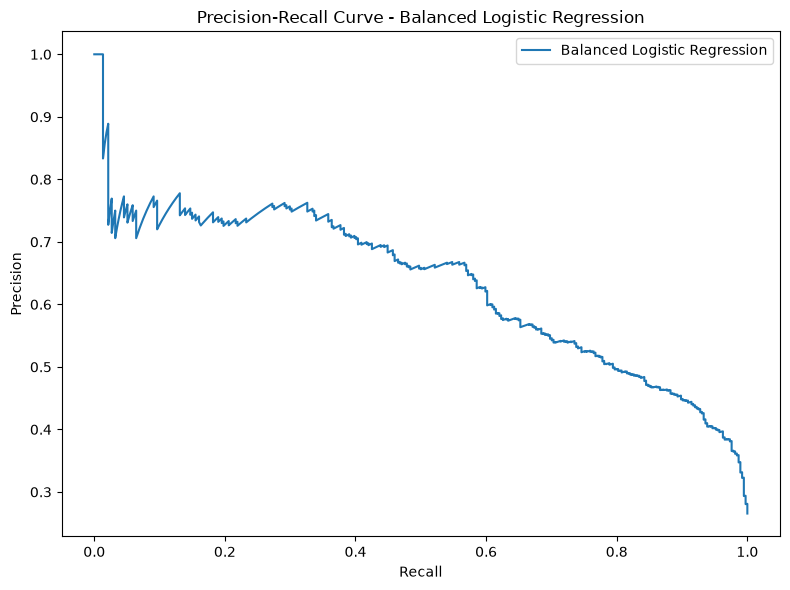

In [99]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_proba_balanced
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label="Balanced Logistic Regression"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Balanced Logistic Regression")
plt.legend()

plt.tight_layout()
plt.show()

#### Precision-Recall Curve - Key Findings

The Precision-Recall curve illustrates the trade-off between precision and recall for the churn class.

Higher recall values are generally associated with lower precision, meaning that identifying more potential churners also results in more false positive predictions.

The model maintains relatively high precision at lower recall levels, while precision decreases as recall approaches 1.0.

This curve confirms the trade-off observed in the classification report and confusion matrix.

The choice of classification threshold should therefore depend on the relative importance of detecting churned customers versus avoiding false positive predictions.

#### Final Evaluation Summary

The balanced Logistic Regression model achieves a ROC-AUC of 0.842 and a recall of 0.783 for the churn class.

The model successfully identifies a larger proportion of churned customers compared with the original Logistic Regression model, although this results in lower precision and overall accuracy.

The evaluation shows that no single metric is sufficient to assess the model's performance. Accuracy, precision, recall, F1-score, ROC-AUC, and the confusion matrix provide complementary information about the model's behavior.

The balanced Logistic Regression model will be used for the interpretation and business analysis stages of this project.

## 11. Model Interpretation

Model interpretation helps identify the features that contribute most strongly to the Logistic Regression predictions.

The coefficients of the balanced Logistic Regression model are examined to understand which features are associated with higher or lower predicted probabilities of churn.

These associations describe how the model uses the features to generate predictions and should not be interpreted as causal relationships.

In [100]:
top_positive = (
    coefficient_df
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

top_negative = (
    coefficient_df
    .sort_values("Coefficient", ascending=True)
    .head(10)
)

print("Top Positive Coefficients:")
display(top_positive[["Feature", "Coefficient"]])

print("\nTop Negative Coefficients:")
display(top_negative[["Feature", "Coefficient"]])

Top Positive Coefficients:


,Feature,Coefficient
16,cat__InternetService_Fiber optic,0.707981
36,cat__Contract_Month-to-month,0.657713
3,num__TotalCharges,0.489698
35,cat__StreamingMovies_Yes,0.275392
32,cat__StreamingTV_Yes,0.262166
43,cat__PaymentMethod_Electronic check,0.240275
18,cat__OnlineSecurity_No,0.199030
27,cat__TechSupport_No,0.165519
14,cat__MultipleLines_Yes,0.132843
26,cat__DeviceProtection_Yes,0.074190



Top Negative Coefficients:


,Feature,Coefficient
1,num__tenure,-1.154434
38,cat__Contract_Two year,-0.775518
2,num__MonthlyCharges,-0.676114
15,cat__InternetService_DSL,-0.622465
22,cat__OnlineBackup_No internet service,-0.275403
17,cat__InternetService_No,-0.275403
25,cat__DeviceProtection_No internet service,-0.275403
28,cat__TechSupport_No internet service,-0.275403
31,cat__StreamingTV_No internet service,-0.275403
19,cat__OnlineSecurity_No internet service,-0.275403


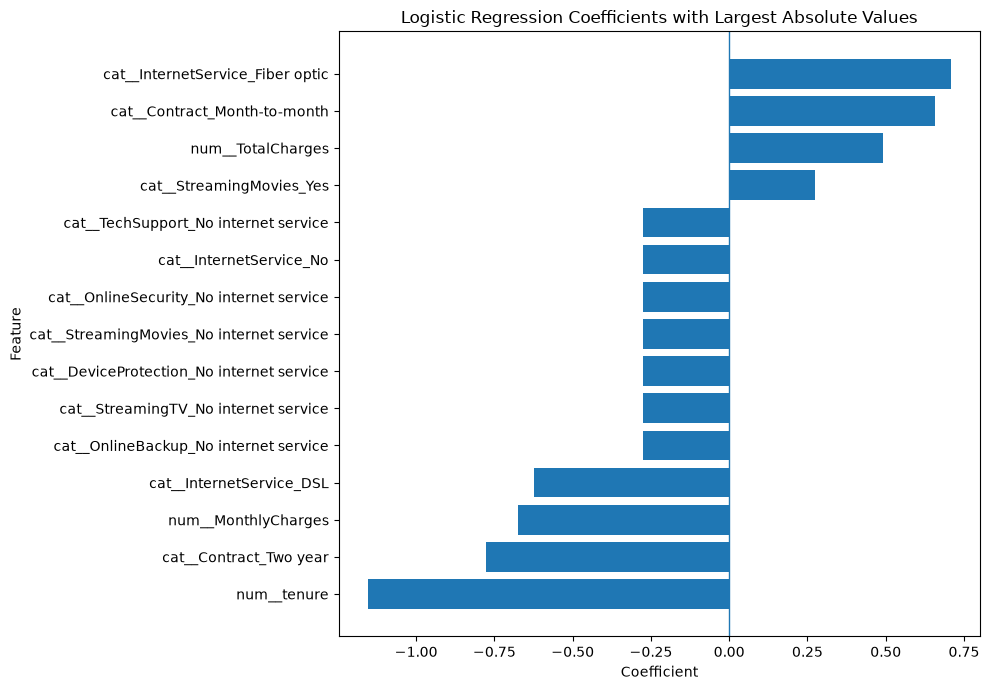

In [101]:
top_coefficients = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(15)

top_coefficients = top_coefficients.sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.axvline(x=0, linewidth=1)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients with Largest Absolute Values")

plt.tight_layout()
plt.show()

### Key Findings

The coefficient visualization highlights the features with the largest absolute coefficients in the Logistic Regression model.

Tenure has the strongest negative coefficient, followed by two-year contracts, MonthlyCharges, and DSL Internet service.

On the positive side, Fiber optic Internet service and month-to-month contracts have the largest coefficients, followed by TotalCharges.

The visualization provides a concise overview of the features with the largest absolute model coefficients to the model's predictions.

These coefficients represent associations within the fitted model and should not be interpreted as causal effects.

## 12. Business Insights

The exploratory analysis and machine learning results provide several insights into customer churn.

The analysis identifies customer characteristics that are associated with higher or lower churn rates and highlights areas that could be considered when designing customer retention strategies.

These insights describe patterns observed in the dataset and model predictions and should not be interpreted as causal relationships.

### 12.1. Main Churn Risk Factors

Several customer characteristics are associated with higher churn rates in the dataset.

Customers with month-to-month contracts have a substantially higher churn rate than customers with one-year or two-year contracts.

Customers with shorter tenure also show higher churn rates, while longer-tenure customers are more frequently associated with no churn.

Higher churn rates are also observed among customers using Fiber optic Internet service and among customers using electronic check as their payment method.

Customers without Online Security or Tech Support also show higher churn rates.

These patterns can help identify customer segments that may require closer attention from a retention perspective.

### 12.2. Potential Retention Areas

The analysis suggests several areas that could be investigated further for customer retention.

Customers with short tenure could be monitored during the early stages of their subscription.

Customers on month-to-month contracts could also represent an important segment for further analysis.

The higher churn rate observed among Fiber optic customers and customers using electronic checks suggests that these segments could be investigated to better understand the reasons behind their churn.

These observations do not establish causal relationships. Further analysis would be required to determine which factors directly influence customer retention.

## 13. Model Limitations

Although the Logistic Regression model provides useful predictions of customer churn, several limitations should be considered when interpreting the results.

The model performance depends on the available features, preprocessing choices, and the classification threshold.

The dataset contains an imbalance between churned and non-churned customers, which affects the interpretation of accuracy and motivated the use of class weighting.

The model also captures associations between variables and churn rather than causal relationships.

Finally, the evaluation was performed on a single train-test split. Additional validation, such as cross-validation and testing on new data, would provide a more robust assessment of the model's generalization performance.

### 13.1. Main Limitations

#### Class Imbalance

The dataset contains substantially more non-churned customers than churned customers.

As a result, accuracy alone is not sufficient to evaluate the model. Precision, recall, F1-score, ROC-AUC, and the confusion matrix were therefore also considered.

#### Model Complexity

Logistic Regression is relatively simple and interpretable, but it may not capture complex non-linear relationships between customer characteristics and churn.

Other models could be investigated in future iterations, including gradient boosting methods or other non-linear algorithms.

#### Feature Limitations

The model can only use the information available in the dataset.

Additional customer information, behavioral data, or historical interactions could potentially provide further predictive information.

#### Generalization

The current evaluation is based on a single train-test split.

Cross-validation and evaluation on an independent dataset would provide stronger evidence about how well the model generalizes to unseen customers.

### 13.2 Future Improvements

Several improvements could be explored in future iterations of the project:

- Apply cross-validation to obtain a more robust estimate of model performance.
- Perform hyperparameter tuning.
- Evaluate additional machine learning models.
- Investigate feature engineering and potential feature interactions.
- Compare different classification thresholds based on specific business costs.
- Evaluate the model on new or external data to assess generalization.
- Investigate probability calibration if predicted churn probabilities are used for decision-making.

## 14. Final Project Summary

This project focused on predicting customer churn using the Telco Customer Churn dataset.

The analysis began with exploratory data analysis to understand the customer population and identify patterns associated with churn.

Several important patterns were identified, including higher churn rates among customers with month-to-month contracts, shorter tenure, Fiber optic Internet service, electronic check payment methods, and customers without Online Security or Tech Support.

The data was then prepared for machine learning by converting numerical variables, handling missing values, encoding categorical variables using one-hot encoding, and scaling numerical features.

Two baseline machine learning models were evaluated: Logistic Regression and Random Forest.

Logistic Regression achieved an accuracy of 0.806 and a ROC-AUC of 0.842, while Random Forest achieved an accuracy of 0.775 and a ROC-AUC of 0.819 on the test set.

Because the dataset contains a class imbalance, a balanced Logistic Regression model was also evaluated. The balanced model increased recall for the churn class from 0.559 to 0.783, while precision decreased from 0.657 to 0.504.

The balanced model achieved a ROC-AUC of 0.842 and an F1-score of 0.614 for the churn class.

Overall, the project demonstrates the complete workflow of a customer churn prediction problem, from data exploration and preprocessing to model evaluation, interpretation, and business insights.

The results provide a foundation for further improvements, including cross-validation, hyperparameter tuning, feature engineering, evaluation of additional models, and testing on new data.

### 14.1. Final Model Performance

| Metric | Balanced Logistic Regression |
|---|---:|
| Accuracy | 0.738 |
| Precision (Churn) | 0.504 |
| Recall (Churn) | 0.783 |
| F1-score (Churn) | 0.614 |
| ROC-AUC | 0.842 |

The model achieves a recall of 0.783 for the churn class, meaning that it identifies a substantial proportion of customers who actually churn.

The results should be interpreted together rather than relying on a single metric.

### 14.2 Conclusion

This project provided an end-to-end analysis of customer churn prediction using Python and scikit-learn.

The analysis combined exploratory data analysis, data preprocessing, machine learning, class imbalance handling, threshold analysis, model interpretation, and business-oriented insights.

The results demonstrate the importance of selecting evaluation metrics that reflect the objective of the prediction task. In particular, recall and precision provide complementary information that is not captured by accuracy alone.

The project also highlights the importance of interpreting machine learning results carefully and distinguishing predictive associations from causal relationships.